In [124]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plot 
from sklearn.linear_model import LinearRegression

In [125]:
data_df=pd.read_csv("advertising .csv")

In [126]:
x=data_df["TV"].to_numpy()
y=data_df["sales"].to_numpy()

In [127]:
from sklearn.model_selection import train_test_split

In [128]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=909)

In [129]:
from sklearn.linear_model import LinearRegression
lin_reg=LinearRegression()
lin_reg.fit(x_train.reshape(-1,1),y_train.reshape(-1,1))

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[0.05]]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[7.04]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[1064.21]


In [130]:
lin_reg.coef_

array([[0.04710336]])

In [131]:
lin_reg.intercept_

array([7.04206318])

In [132]:
y_pred=lin_reg.predict(x_test.reshape(-1,1))
sse=np.sum(np.power((y_test.reshape(-1,1)-y_pred.reshape(-1,1)),2))
sse

np.float64(350.3553922682761)

In [133]:
x_test.shape

(40,)

# PERFORMANCE METRICS

In [134]:
from sklearn.metrics import max_error,mean_absolute_error,mean_squared_error
max_error(y_test.reshape(-1,1),y_pred.reshape(-1,1))

7.289078438466312

In [135]:
mean_absolute_error(y_test,y_pred)

2.338255454577244

In [136]:
mean_squared_error(y_test,y_pred)

8.758884806706902

In [137]:
from sklearn.metrics import r2_score

In [138]:
r2_score(y_test,y_pred)

0.6956649384057587

In [139]:
data_df

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
...,...,...,...,...,...
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5


# for radio and sales 

In [140]:
data_df.corr() # moderate corelation so lets see

,Unnamed: 0,TV,radio,newspaper,sales
Unnamed: 0,1.000000,0.017715,-0.110680,-0.154944,-0.051616
TV,0.017715,1.000000,0.054809,0.056648,0.782224
radio,-0.110680,0.054809,1.000000,0.354104,0.576223
newspaper,-0.154944,0.056648,0.354104,1.000000,0.228299
sales,-0.051616,0.782224,0.576223,0.228299,1.000000


In [141]:
x=data_df.radio.to_numpy()
y=data_df.sales.to_numpy()

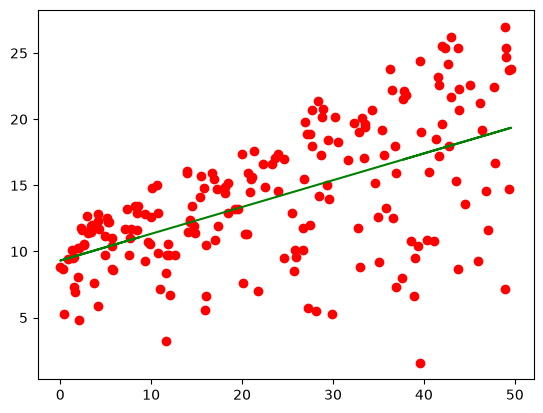

In [142]:
from sklearn.linear_model import LinearRegression 
linear_reg=LinearRegression()
linear_reg.fit(x.reshape(-1,1),y.reshape(-1,1))
plot.scatter(x,y,color="red")
plot.plot(x,linear_reg.predict(x.reshape(-1,1)),color="green")

In [143]:
linear_reg.coef_ # beta values 


array([[0.20249578]])

In [144]:
linear_reg.intercept_ # value of beta_0
y_cap=linear_reg.predict(x.reshape(-1,1))

In [145]:
# so now sse 
sse=np.sum(np.power((y-y_cap),2))
sse


np.float64(1443163.5901949825)

In [146]:
# so we have to check now we do train vs test 
from sklearn.model_selection import train_test_split

In [147]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=909)

In [148]:
from sklearn.linear_model import LinearRegression
linear_reg=LinearRegression()
linear_reg.fit(x_train.reshape(-1,1),y_train.reshape(-1,1))
print(linear_reg.coef_,linear_reg.intercept_)
y_pred=linear_reg.predict(x_test.reshape(-1,1))
sse=np.sum(np.power(y_test.reshape(-1,1) - y_pred.reshape(-1,1),2))
sse
# .coef_ -> beta values 
# .intercept_ -> beta_0

[[0.19726382]] [9.4837012]


np.float64(753.8842384830757)

In [153]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)
# bad 

0.3451409305611842

In [150]:
from sklearn.metrics import max_error ,mean_absolute_error,mean_squared_error
print(max_error(y_test,y_pred),mean_absolute_error(y_test,y_pred))

10.081889303865399 3.6179798630962368


In [152]:
mean_squared_error(y_test,y_pred)

18.847105962076892